In [5]:
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l
import matplotlib.pyplot as plt


### Exercise 1

How would you need to change the learning rate if you replace the aggregate loss over the minibatch with an average over the loss on the minibatch?

Switching from sum to average shrinks the gradient by a factor of $B$.

To keep the same update size, we must:
$$
\eta_{\text {new }}=B \cdot \eta_{\text {old }}
$$
So we need to increase the learning rate by a factor equal to the batch size.

### Exercise 2

Review the framework documentation to see which loss functions are provided. In particular, replace the squared loss with Huber's obust loss function. That is, use the loss function
$$
l\left(y, y^{\prime}\right)= \begin{cases}\left|y-y^{\prime}\right|-\frac{\sigma}{2} & \text { if }\left|y-y^{\prime}\right|>\sigma \\ \frac{1}{2 \sigma}\left(y-y^{\prime}\right)^2 & \text { otherwise }\end{cases}
$$

In [4]:
@d2l.add_to_class(d2l.Module)
def loss(self, y_hat, y):
    fn = nn.HuberLoss(delta=1.0)   # choose σ here
    return fn(y_hat, y)

### Exercise 3

How do you access the gradient of the weights of the model?

We access gradients via:
* `parameter.grad`

after calling
* `loss.backward()`

For example:
* `print(model.w.grad)`

or more generally:
```
for param in model.parameters():
    print(param.grad)
```

### Exercise 4

What is the effect on the solution if you change the learning rate and the number of epochs? Does it keep on improving?

Changing learning rate and epochs does NOT change the true optimal solution (for convex problems).

It changes:

* Speed of convergence

* Stability

* Whether you converge at all

And no — performance does not improve indefinitely.

It eventually plateaus, and may even worsen on test data.

### Exercise 5

5. How does the solution change as you vary the amount of data generated?
* Plot the estimation error for $\hat{\mathbf{w}}-\mathbf{w}$ and $\hat{b}-b$ as a function of the amount of data. Hint: increase the amount of data logarithmically rather than linearly, i.e., $5,10,20,50, \ldots, 10,000$ rather than $1000,2000, \ldots, 10,000$.
* Why is the suggestion in the hint appropriate?

#### 5.1

In [7]:
class LinearRegression(d2l.Module):  #@save
    """The linear regression model implemented with high-level APIs."""
    def __init__(self, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.LazyLinear(1)
        self.net.weight.data.normal_(0, 0.01)
        self.net.bias.data.fill_(0)

In [8]:
@d2l.add_to_class(LinearRegression)  #@save
def forward(self, X):
    return self.net(X)

In [9]:
@d2l.add_to_class(LinearRegression)  #@save
def configure_optimizers(self):
    return torch.optim.SGD(self.parameters(), self.lr)

In [11]:
@d2l.add_to_class(LinearRegression)  #@save
def get_w_b(self):
    return (self.net.weight.data, self.net.bias.data)

In [14]:
class LinearRegressionNoPlot(LinearRegression):
    def plot(self, key, value, train):
        pass

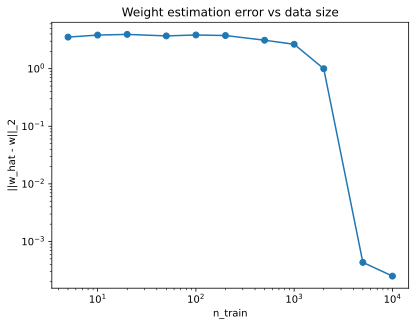

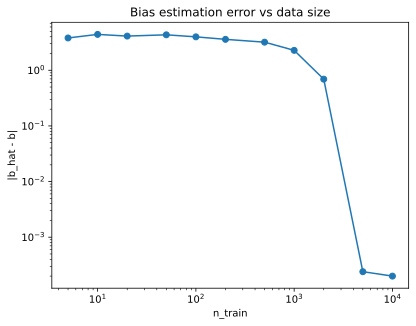

In [16]:
def run_one(n_train, lr=0.03, max_epochs=3, repeats=5, num_val=1000):
    true_w = torch.tensor([2.0, -3.4])
    true_b = 4.2

    w_errs = []
    b_errs = []

    for _ in range(repeats):
        # new data for each repeat
        data = d2l.SyntheticRegressionData(
            w=true_w, b=true_b,
            num_train=n_train, num_val=num_val,
            batch_size=min(32, n_train)  # avoid batch bigger than data
        )

        model = LinearRegressionNoPlot(lr=lr)
        trainer = d2l.Trainer(max_epochs=max_epochs)
        trainer.fit(model, data)

        w_hat, b_hat = model.get_w_b()
        w_hat = w_hat.reshape(true_w.shape)

        # errors (choose your favorite metric)
        w_err = torch.norm(w_hat - true_w).item()     # L2 error of w
        b_err = torch.abs(b_hat - true_b).item()      # absolute error of b

        w_errs.append(w_err)
        b_errs.append(b_err)

    return (sum(w_errs)/len(w_errs), sum(b_errs)/len(b_errs))

ns = [5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]

w_curve = []
b_curve = []

for n in ns:
    w_e, b_e = run_one(n_train=n, lr=0.03, max_epochs=3, repeats=5, num_val=1000)
    w_curve.append(w_e)
    b_curve.append(b_e)

# plot
plt.figure()
plt.plot(ns, w_curve, marker='o')
plt.xscale('log')
plt.yscale('log')  # optional but often nice
plt.xlabel('n_train')
plt.ylabel('||w_hat - w||_2')
plt.title('Weight estimation error vs data size')
plt.show()

plt.figure()
plt.plot(ns, b_curve, marker='o')
plt.xscale('log')
plt.yscale('log')  # optional
plt.xlabel('n_train')
plt.ylabel('|b_hat - b|')
plt.title('Bias estimation error vs data size')
plt.show()

If we increase the data from 1000 to 10,000 linearly. We gonna miss the sudden error decreases threshold in this plot. 

Do the plot in the scale of log helps us know the optimal number of datapoints might be 1000.